In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

# sys.path.append(os.path.expanduser('~/git/desi-examples/misc/plot_spectrum/'))
# import desi_plot_spectrum

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
def get_rr_model(coadd_fn, index, redrock_fn=None, use_targetid=False, coadd_cameras=False, restframe=False, z=None, return_z=False):
    '''
    Return redrock model spectrum.

    Args:
       coadd_fn: str, path of coadd FITS file
       index: int, index of coadd FITS file if use_targetid=False, or TARGETID if use_targetid=True

    Options:
       redrock_fn, str, path of redrock FITS file
       use_targetid: bool, if True, index is TARGETID
       coadd_cameras: bool, if True, the BRZ cameras are coadded together
       restframe: bool, if True, return restframe spectrum in template wavelength grid; if False,
       return spectrum in three cameras in observed frame
       z: bool, if None, use redrock best-fit redshift
       return_z: bool, if true, include redshift in output
    '''
    # If use_targetid=False, index is the index of coadd file; if True, index is TARGETID.

    from desispec.interpolation import resample_flux
    import redrock.templates
    from desispec.io import read_spectra

    spec = read_spectra(coadd_fn)

    if redrock_fn is None:
        redrock_fn = coadd_fn.replace('/coadd-', '/redrock-')
    redshifts = Table(fitsio.read(redrock_fn, ext='REDSHIFTS'))

    if use_targetid:
        coadd_index = np.where(redshifts['TARGETID']==index)[0][0]
    else:
        coadd_index = index
    if z is None:
        z = redshifts['Z'][coadd_index]

    templates = dict()
    for filename in redrock.templates.find_templates():
        tx = redrock.templates.Template(filename)
        templates[(tx.template_type, tx.sub_type)] = tx

    tx = templates[(redshifts['SPECTYPE'][coadd_index], redshifts['SUBTYPE'][coadd_index])]
    coeff = redshifts['COEFF'][coadd_index][0:tx.nbasis]

    if restframe==False:
        wave = dict()
        model_flux = dict()
        if coadd_cameras:
            cameras = ['BRZ']
        else:
            cameras = ['B', 'R', 'Z']
        for camera in cameras:
            wave[camera] = spec.wave[camera.lower()]
            model_flux[camera] = np.zeros(wave[camera].shape)
            model = tx.flux.T.dot(coeff).T
            mx = resample_flux(wave[camera], tx.wave*(1+z), model)
            model_flux[camera] = spec.R[camera.lower()][coadd_index].dot(mx)
    else:
        wave = tx.wave
        model_flux = tx.flux.T.dot(coeff).T

    if return_z:
        return wave, model_flux, z
    else:
        return wave, model_flux


def plot_spectrum(coadd_fn, index, redrock_fn=None, use_targetid=False, coadd_cameras=False,
    show_lines=True, show_restframe=True, show_model=True, figsize=(22, 5), lw=1.2, gauss_smooth=3,
    label=None, title=None, show=True, return_ax=False, xlim=[3400, 10000], ylim=None, grid=False):
    '''
    Plot DESI spectrum.

    Args:
       coadd_fn: str, path of coadd FITS file
       index: int, index of coadd FITS file if use_targetid=False, or TARGETID if use_targetid=True

    Options:
       use_targetid: bool, if True, index is TARGETID
       redrock_fn, str, path of redrock FITS file
       use_targetid: bool, if True, index is TARGETID
       coadd_cameras: bool, if True, the BRZ cameras are coadded together
    '''

    # from scipy.ndimage import gaussian_filter1d
    from astropy.convolution import Gaussian1DKernel, convolve
    from matplotlib.ticker import AutoMinorLocator

    # lines = {
    #     'Ha'      : 6562.8,
    #     'Hb'       : 4862.68,
    #     'Hg'       : 4340.464,
    #     'Hd'       : 4101.734,
    #     # 'OIII-b'       :  5006.843,
    #     # 'OIII-a'       : 4958.911,
    #     'OIII': 4982.877,
    #     'MgII'    : 2799.49,
    #     'OII'         : 3728,
    #     'CIII'  : 1909.,
    #     'CIV'    : 1549.06,
    #     'SiIV'  : 1393.76018,
    #     'LYA'         : 1215.67,
    #     'LYB'         : 1025.72
    # }
    
    lines = [
    # Major absorption lines
    ['K', 3933.7, 1],
    ['H', 3968.5, 2],
    ['G', 4307.74, 0],
    ['Mg I', 5175.0, 0],
    ['D2', 5889.95, 0],
    ['D1', 5895.92, 1],

    # Major emission lines
    [r'Ly$alpha$', 1215.67, 0],
    ['C IV', 1549.48, 0],
    ['C III]', 1908.734, 0],
    ['Mg II', 2796.3543, 0],
    ['Mg II', 2803.5315, 1],
    # ['[O II]', 3726.032, 0],
    # ['[O II]', 3728.815, 1],
    ['[O II]', 3727.424, 0],
    ['[Ne III]', 3868.76, 0],
    [r'H$\delta$', 4101.734, 0],
    [r'H$\gamma$', 4340.464, 1],
    [r'H$\beta$', 4861.325, 0],
    ['[O III]', 4958.911, 0],
    ['[O III]', 5006.843, 1],
    [r'H$\alpha$', 6562.801, 0],
    ['[N II]', 6583.45, 1],
    ['[S II]', 6716.44, 0],
    ['[S II]', 6730.82, 1],
    ]

    line_names = [tmp[0] for tmp in lines]

    tmp = fitsio.read(coadd_fn, columns=['TARGETID'], ext='FIBERMAP')

    if use_targetid:
        tid = index
        coadd_index = np.where(tmp['TARGETID']==index)[0][0]
    else:
        tid = tmp['TARGETID'][index]
        coadd_index = index

    if show_model:
        # Get model spectrum
        _, model_flux = get_rr_model(coadd_fn, coadd_index, redrock_fn=redrock_fn, coadd_cameras=coadd_cameras)

    if redrock_fn is None:
        redrock_fn = coadd_fn.replace('/coadd-', '/redrock-')
    redshifts = Table(fitsio.read(redrock_fn, ext='REDSHIFTS'))
    fibermap = Table(fitsio.read(redrock_fn, ext='FIBERMAP'))
    fibermap.remove_column('TARGETID')
    redshifts = hstack([redshifts, fibermap])
    z = redshifts['Z'][coadd_index]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        redshifts['gmag'] = 22.5 - 2.5*np.log10(redshifts['FLUX_G']) - 3.214 * redshifts['EBV']
        redshifts['rmag'] = 22.5 - 2.5*np.log10(redshifts['FLUX_R']) - 2.165 * redshifts['EBV']
        redshifts['zmag'] = 22.5 - 2.5*np.log10(redshifts['FLUX_Z']) - 1.211 * redshifts['EBV']
        redshifts['w1mag'] = 22.5 - 2.5*np.log10(redshifts['FLUX_W1']) - 0.184 * redshifts['EBV']
        redshifts['w2mag'] = 22.5 - 2.5*np.log10(redshifts['FLUX_W2']) - 0.113 * redshifts['EBV']
        redshifts['gfibermag'] = 22.5 - 2.5*np.log10(redshifts['FIBERFLUX_G']) - 3.214 * redshifts['EBV']
        redshifts['rfibermag'] = 22.5 - 2.5*np.log10(redshifts['FIBERFLUX_R']) - 2.165 * redshifts['EBV']
        redshifts['zfibermag'] = 22.5 - 2.5*np.log10(redshifts['FIBERFLUX_Z']) - 1.211 * redshifts['EBV']

    ymin, ymax = 0., 0.

    fig, ax1 = plt.subplots(figsize=figsize)
    if coadd_cameras:
        cameras = ['BRZ']
    else:
        cameras = ['B', 'R', 'Z']
    for camera in cameras:
        wave = fitsio.read(coadd_fn, ext=camera+'_WAVELENGTH')
        # wave_rest = wave/(1+z)
        flux = fitsio.read(coadd_fn, ext=camera+'_FLUX')[coadd_index]
        msk = fitsio.read(coadd_fn, ext=camera+'_MASK')[coadd_index]
        ivar = fitsio.read(coadd_fn, ext=camera+'_IVAR')[coadd_index]
        bad = msk!=0
        # flux[bad] = 0.
        flux[bad] = np.nan
        if show_model:
            model_flux[camera][bad] = np.nan
        # if np.sum(bad)!=0:
        #     print('{} masked pixels: {}'.format(camera, np.sum(bad)))

        if gauss_smooth==0 or gauss_smooth is None:
            flux_smooth = flux.copy()
        elif gauss_smooth>0:
            # flux_smooth = gaussian_filter1d(flux, gauss_smooth, mode='constant', cval=0)
            gauss_kernel = Gaussian1DKernel(stddev=gauss_smooth)
            flux_smooth = convolve(flux, gauss_kernel, boundary='extend')

        if camera=='B' or camera=='BRZ':
            if label is not None:
                plot_label = label
            else:
                plot_label = 'TARGETID={}'.format(tid)
                plot_label += '  g={:.2f} r={:.2f} z={:.2f} W1={:.2f} zfiber={:.2f}'.format(
                    redshifts['gmag'][coadd_index], redshifts['rmag'][coadd_index], redshifts['zmag'][coadd_index], redshifts['w1mag'][coadd_index], redshifts['zfibermag'][coadd_index])
                plot_label += '\nRedshift={:.4f}  TYPE={}  ZWARN={}  DELTACHI2={:.1f}'.format(
                    z, redshifts['SPECTYPE'][coadd_index], redshifts['ZWARN'][coadd_index], redshifts['DELTACHI2'][coadd_index])
        else:
            plot_label = None

        ax1.plot(wave, flux_smooth, lw=lw, label='data', color='C0')
        if show_model:
            if gauss_smooth==0 or gauss_smooth is None:
                model_flux_smooth = model_flux[camera].copy()
            elif gauss_smooth>0:
                # model_flux_smooth = gaussian_filter1d(model_flux[camera], gauss_smooth, mode='constant', cval=0)
                model_flux_smooth = convolve(model_flux[camera], gauss_kernel, boundary='extend')
            ax1.plot(wave, model_flux_smooth, lw=3, color='r', alpha=0.4, label='best-fit model')
        ymin = np.minimum(ymin, 1.3 * np.percentile(flux_smooth[np.isfinite(flux_smooth)], 1.))
        ymax = np.maximum(ymax, 1.3 * np.percentile(flux_smooth[np.isfinite(flux_smooth)], 99.))

    if ylim is None:
        ylim = [ymin, ymax]
    if show_lines:
        for line_index in range(len(lines)):
            line_name, line_wavelength, text_offset = lines[line_index]
            if (line_wavelength*(1+z)>3400) & (line_wavelength*(1+z)<10000):
                ax1.axvline(line_wavelength*(1+z), lw=lw, color='C2', alpha=1, ls='--')
                text_yposition = 0.96*ylim[0]+0.04*ylim[1]
                text_yposition += 0.05*(ylim[1]-ylim[0])*text_offset
                ax1.text(line_wavelength*(1+z)+7, text_yposition, line_name, fontsize=plt.rcParams['legend.fontsize'])
    ax1.text(3450, 0.04*ylim[0]+0.96*ylim[1], plot_label, verticalalignment='top',
            fontsize=plt.rcParams['legend.fontsize'], bbox=dict(facecolor='white', alpha=0.7))
    ax1.axis([xlim[0], xlim[1], ylim[0], ylim[1]])
    ax1.set_xlabel('observed wavelength ($\AA$)')
    # plt.axvline(4000, ls='--', lw=1, color='k')
    # ax1.legend(loc='upper left', handletextpad=.0, handlelength=0)
    ax1.legend(loc=(0.885, 0.16))
    if grid:
        ax1.grid()
    if title is not None:
        ax1.set_title(title)
    if show_restframe:
        ax2 = ax1.twiny()
        ax2.set_xlim(3400/(1+z), 10000/(1+z))
        ax2.set_xlabel('restframe wavelength ($\AA$)')
        ax1.set_ylabel('flux ($10^{-17}$ ergs/s/cm$^2$/$\AA$)')
    ax1.xaxis.set_minor_locator(AutoMinorLocator())
    ax1.tick_params(axis="both", which='both', direction="in", top=False, right=True)
    ax2.xaxis.set_minor_locator(AutoMinorLocator())
    ax2.tick_params(which='both', direction="in")
    plt.tight_layout()
    # plt.savefig('/global/cfs/cdirs/desi/users/rongpu/plots/lrg_speed/spectra_low_speed_failures/{}_deep.png'.format(tid))
    if show:
        plt.show()

    if return_ax:
        if show_restframe:
            return ax1, ax2
        else:
            return ax1

In [4]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_lrg.fits'))
print(len(cat))

# cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove duplidates keeping the higher EFFTIME objects
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])), len(cat)-len(np.unique(cat['TARGETID'])))

mask = cat['TILEID']==1242
cat = cat[mask]
print(len(cat))

mask = cat['EFFTIME_LRG']>900
print('EFFTIME', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
cat['q'] = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
cat['q'] &= cat['Z']<1.4
cat['q'] &= cat['ZWARN']<1.4
mask = cat['q'].copy()
print('Redshift quality', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]
print(len(cat))

345431
FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
299639 299609 30
299609 299609 0
1121
EFFTIME 1033 88 0.07850133809099019
Redshift quality 1027 6 0.005808325266214908
1027


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

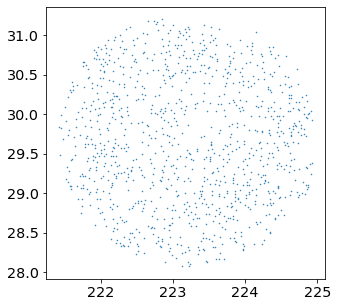

In [6]:
plt.figure(figsize=(5, 5))
plt.plot(cat['TARGET_RA'], cat['TARGET_DEC'], '.', ms=1)
plt.show()

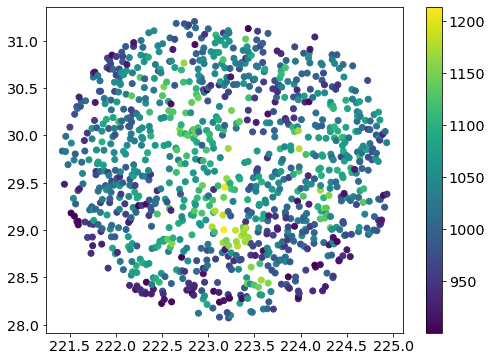

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(cat['TARGET_RA'], cat['TARGET_DEC'], c=cat['EFFTIME_LRG'])
plt.colorbar()
plt.show()

In [8]:
# np.random.seed(342197)
# idx = np.random.choice(len(cat), size=6, replace=False)
# cat1 = cat[idx].copy()
# cat1.sort('Z')
# cat1

In [9]:
# idx = [891, 472, 658, 882, 60, 881]
# idx = [891, 472, 658, 363, 60, 881]
idx = [891, 472, 658, 958, 60, 881]
cat1 = cat[idx].copy()
cat1

TARGETID,Z,ZERR,ZWARN,CHI2,SPECTYPE,SUBTYPE,DELTACHI2,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,COADD_FIBERSTATUS,TARGET_RA,TARGET_DEC,FIBERASSIGN_X,FIBERASSIGN_Y,MORPHTYPE,EBV,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FIBERFLUX_Z,MASKBITS,PARALLAX,PHOTSYS,DESI_TARGET,BGS_TARGET,TILEID,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,TSNR2_ELG,TSNR2_BGS,TSNR2_QSO,TSNR2_LRG,LASTNIGHT,fn,lrg_mask,EFFTIME_LRG,q,gmag,rmag,zmag,w1mag,w2mag,zfibermag
int64,float64,float64,int64,float64,str6,str20,float64,int16,int32,int64,int32,int32,float64,float64,float32,float32,str4,float32,float32,float32,float32,float32,float32,float32,int16,float32,str1,int64,int64,int32,int16,float32,int16,int16,float32,float32,float32,float32,int64,str73,int16,float32,bool,float32,float32,float32,float32,float32,float32
39628496997190333,0.4380309798177667,5.4193574165259893e-05,0,7660.6516416966915,GALAXY,,632.6627738028765,4,484,4484,2163,0,221.959007424655,30.84776176497747,271.59454,296.41345,SER,0.015903892,1.8868511,10.93747,28.267216,57.999416,36.386196,10.9204035,0,0.0,S,65537,0,1242,1,727.0249,1,1,99.687996,6255.968,26.69069,74.954765,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-4-1242-thru20210606.fits,0,910.7004,True,21.75954,19.868277,18.852531,18.088514,18.595861,19.885143
39628470854094084,0.6090927827814455,0.00013902545711865066,0,7780.279508974403,GALAXY,,227.61460860818624,9,13,9013,4896,0,223.46217862561866,29.45966008773759,-54.600727,-53.96193,DEV,0.019781064,0.9784944,4.060538,12.545519,49.545166,45.133766,4.190229,0,0.0,S,65537,0,1242,1,727.0249,1,1,122.52545,6566.213,32.416336,80.29909,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-9-1242-thru20210606.fits,0,975.6339,True,22.460028,20.935715,19.729824,18.258858,18.361511,20.920452
39628481352436222,0.7419956283891902,7.748033758012119e-05,0,7616.343583136797,GALAXY,,166.700141325593,4,10,4010,2125,0,223.04734021570673,29.9168109960237,33.33311,57.080124,EXP,0.01757761,0.363828,2.1904857,11.7646055,58.00304,33.424152,3.2578201,0,0.0,S,65537,0,1242,1,727.0249,1,1,119.97102,7334.241,33.105667,89.689964,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-4-1242-thru20210606.fits,0,1089.733,True,23.541265,21.610594,19.80227,18.088139,18.687864,21.196396
39628497026551826,0.8947658023189127,0.00016465383896239205,0,7669.120577540249,GALAXY,,159.74476751312613,6,383,6383,3181,0,224.08448340905267,30.8178514188316,-188.81776,285.71378,REX,0.019960918,0.08772049,0.7696807,5.3228254,27.250706,16.374596,2.842778,0,0.0,S,65537,0,1242,1,727.0249,1,1,117.469864,6760.918,30.983248,86.832825,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-6-1242-thru20210606.fits,0,1055.0188,True,25.078094,22.741009,20.660473,18.907883,19.462317,21.34147
39628449681245906,1.0101315836671716,0.00011062236150745654,0,7803.137479096651,GALAXY,,110.13946824148297,1,401,1401,504,0,222.3900108375496,28.424398042405418,179.76448,-316.03754,REX,0.019572778,0.88432133,1.9073387,7.4724364,39.339405,33.4002,2.2617438,0,0.0,S,65537,0,1242,1,727.0249,1,1,111.214775,6666.4893,29.272896,84.69096,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-1-1242-thru20210606.fits,0,1028.9951,True,22.570568,21.756556,20.292643,18.509329,18.688416,21.590189
39628491829807705,1.1463891570106453,0.0002534444425051328,0,7618.379497017711,GALAXY,,100.72417329065502,7,416,7416,3764,0,224.7240024564718,30.579177635884015,-331.0705,230.14024,REX,0.016836707,0.07811665,0.46735963,3.6030352,21.119455,18.632679,2.3091943,0,0.0,S,65537,0,1242,1,727.0249,1,1,113.57983,6516.963,30.226347,79.81654,20210606,guadalupe/tiles/cumulative/1242/20210606/redrock-7-1242-thru20210606.fits,0,969.771,True,25.214027,23.289421,21.087938,19.185196,19.32241,21.57096


In [10]:
tids = np.array(cat1['TARGETID'])
tids

array([39628496997190333, 39628470854094084, 39628481352436222,
       39628497026551826, 39628449681245906, 39628491829807705])

In [11]:
t = Table()
t['RA'] = cat['TARGET_RA'][idx]
t['DEC'] = cat['TARGET_DEC'][idx]
t.write('plots/visual_inspection.txt', format='ascii.no_header', overwrite=True)

In [12]:
# zmin, zmax = 0.8, 0.9333333333333333
# mask = (cat['Z']>zmin) & (cat['Z']<zmax)

# print(np.median(cat['DELTACHI2'][mask]))
# plt.hist(cat['DELTACHI2'][mask], 30, range=(0, 500));

# zmin, zmax = 0.8, 0.9333333333333333
# mask = (cat['Z']>zmin) & (cat['Z']<zmax)
# mask &= cat['DELTACHI2']>150
# cat[mask]

# np.where(cat['TARGETID']==39628497026551826)

In [13]:
# np.random.seed(706675)

# idx = []
# zranges = np.linspace(0.4, 1.2, 7)
# for index in range(len(zranges)-1):
#     zmin, zmax = zranges[index], zranges[index+1]
#     print(zmin, zmax)
#     mask = (cat['Z']>zmin) & (cat['Z']<zmax)
#     print(np.sum(mask))
#     idx.append(np.random.choice(np.where(mask)[0]))
    
# print(idx)
# cat1 = cat[idx].copy()
# cat1

In [14]:
yranges = [
[-0.5, 2.6], 
[-0.5, 1.5],
[-0.8, 1.2],
[-0.8, 1.2],
[-0.5, 1.],
[-0.5, 1.],
]

In [29]:
for index in range(len(cat1)):
    os.system('wget -O plots/cutout_{}_grz.png \'https://www.legacysurvey.org/viewer/cutout.jpg?ra={}&dec={}&pixscale=0.262&layer=ls-dr9&size=130\''.format(index, cat1['TARGET_RA'][index], cat1['TARGET_DEC'][index]))
    os.system('wget -O plots/cutout_{}_wise.png \'https://www.legacysurvey.org/viewer/cutout.jpg?ra={}&dec={}&pixscale=0.262&layer=unwise-neo6&size=130\''.format(index, cat1['TARGET_RA'][index], cat1['TARGET_DEC'][index]))

--2022-03-06 13:37:54--  https://www.legacysurvey.org/viewer/cutout.jpg?ra=221.959007424655&dec=30.84776176497747&pixscale=0.262&layer=ls-dr9&size=130
Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.109, 128.55.206.107, 128.55.206.111, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.109|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10263 (10K) [image/jpeg]
Saving to: ‘plots/cutout_0_grz.png’

     0K ..........                                            100% 25.0M=0s

2022-03-06 13:37:58 (25.0 MB/s) - ‘plots/cutout_0_grz.png’ saved [10263/10263]

--2022-03-06 13:37:58--  https://www.legacysurvey.org/viewer/cutout.jpg?ra=221.959007424655&dec=30.84776176497747&pixscale=0.262&layer=unwise-neo6&size=130
Resolving www.legacysurvey.org (www.legacysurvey.org)... 128.55.206.111, 128.55.206.110, 128.55.206.109, ...
Connecting to www.legacysurvey.org (www.legacysurvey.org)|128.55.206.111|:443... connected.
HTTP request sent

INFO:spectra.py:285:read_spectra: iotime 0.447 sec to read coadd-4-1242-thru20210606.fits at 2022-03-06T18:33:25.606530
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

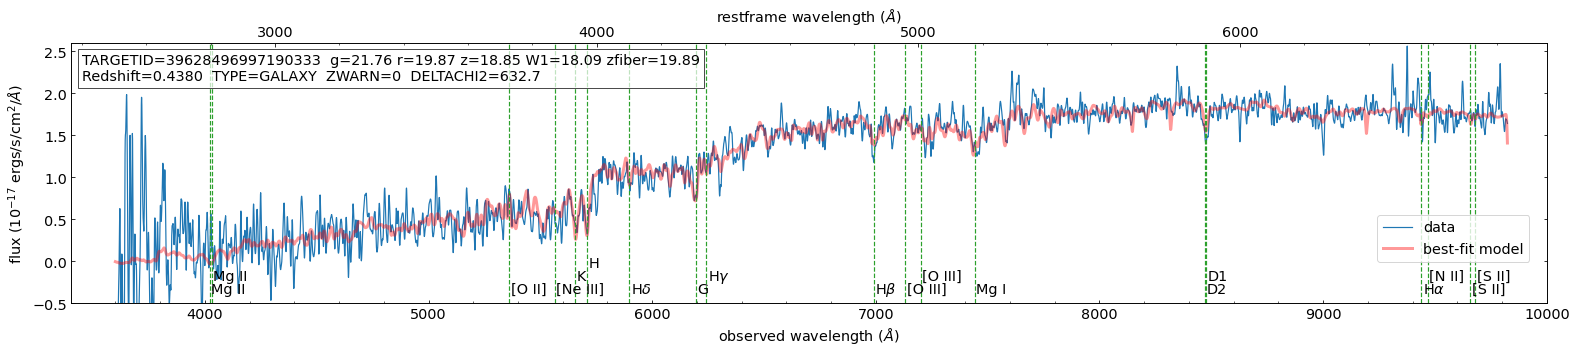

INFO:spectra.py:285:read_spectra: iotime 0.450 sec to read coadd-9-1242-thru20210606.fits at 2022-03-06T18:33:28.231871
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

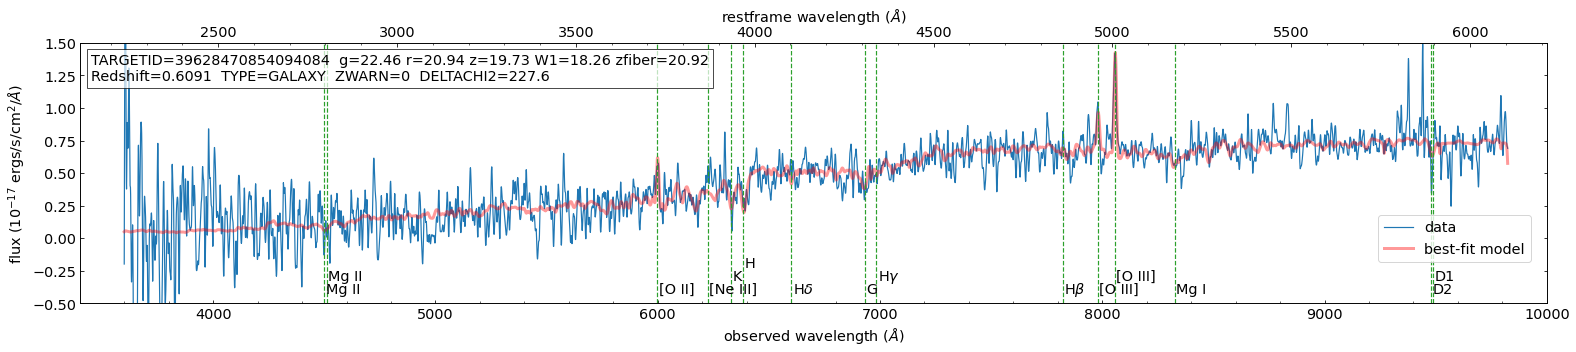

INFO:spectra.py:285:read_spectra: iotime 0.441 sec to read coadd-4-1242-thru20210606.fits at 2022-03-06T18:33:31.022948
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

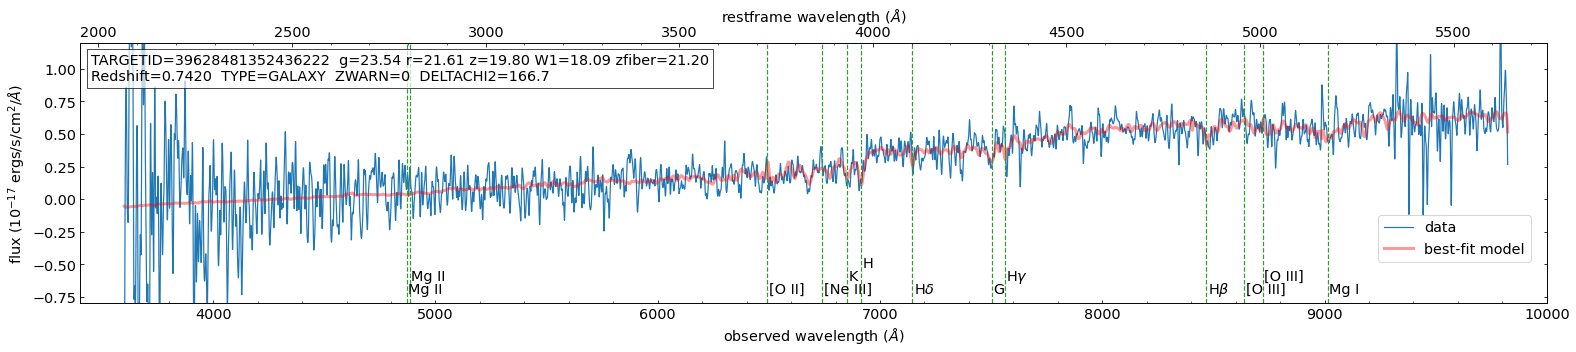

INFO:spectra.py:285:read_spectra: iotime 0.449 sec to read coadd-6-1242-thru20210606.fits at 2022-03-06T18:33:33.652330
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

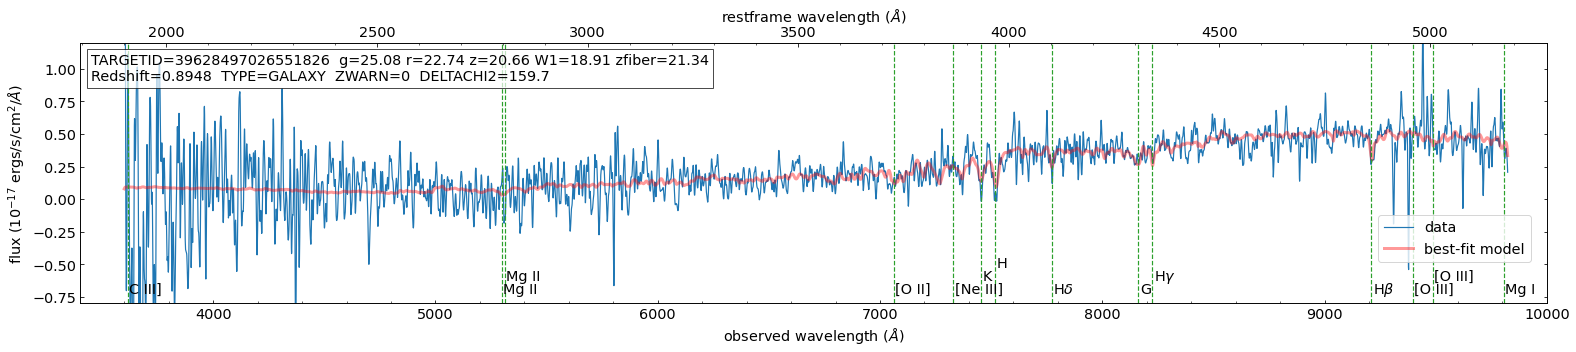

INFO:spectra.py:285:read_spectra: iotime 0.467 sec to read coadd-1-1242-thru20210606.fits at 2022-03-06T18:33:36.215356
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

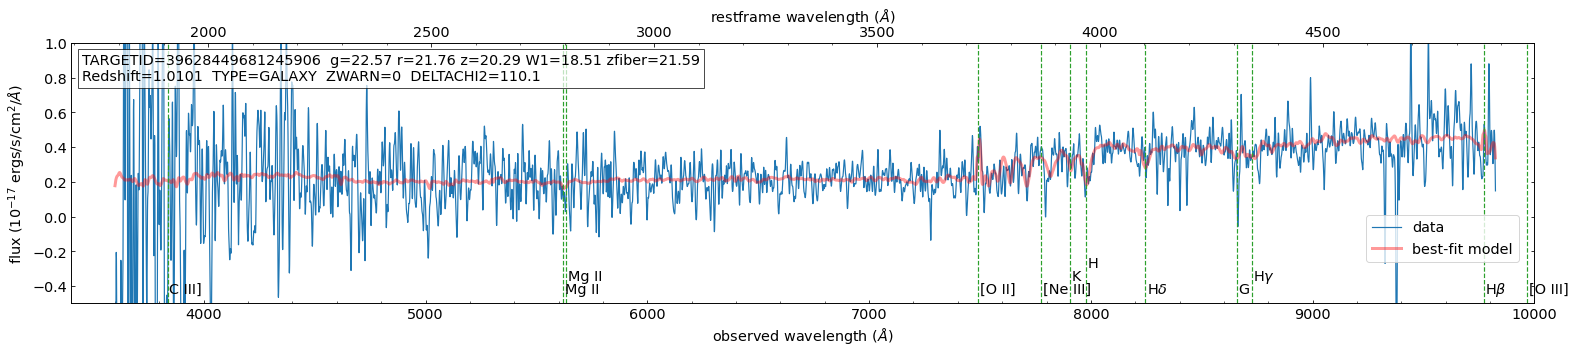

INFO:spectra.py:285:read_spectra: iotime 0.451 sec to read coadd-7-1242-thru20210606.fits at 2022-03-06T18:33:38.774353
DEBUG: Read templates from /global/common/software/desi/cori/desiconda/20211217-2.0.0/code/redrock-templates/master
DEBUG: Using default redshift range -0.0050-1.6997 for rrtemplate-galaxy.fits
DEBUG: Using default redshift range 0.0500-5.9934 for rrtemplate-qso.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-A.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-B.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-CV.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-F.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-G.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-K.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate-star-M.fits
DEBUG: Using default redshift range -0.0020-0.0020 for rrtemplate

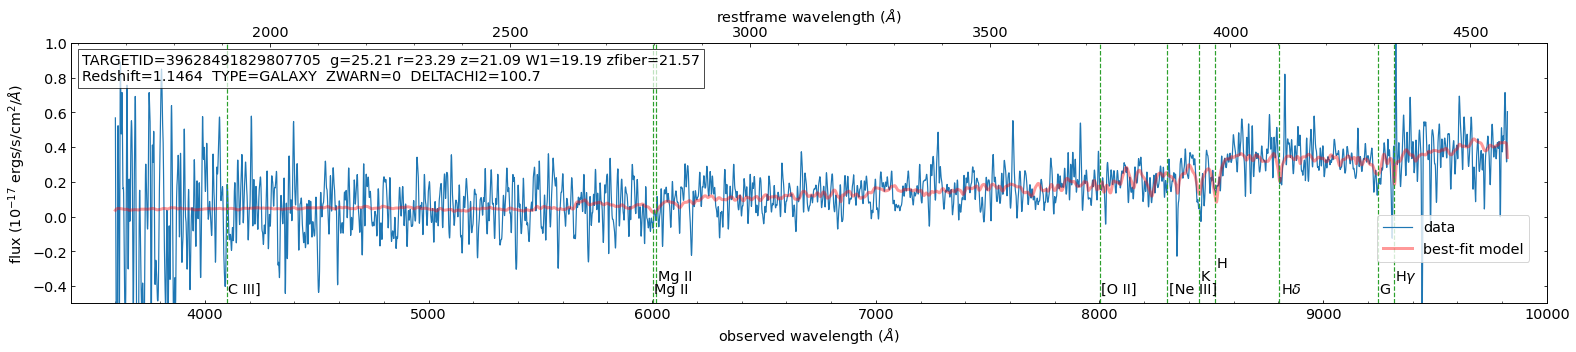

In [32]:
for index in range(len(cat1)):
    coadd_fn = '/global/cfs/cdirs/desi/users/rongpu/data/lrg/example_spectra/'+os.path.basename(cat1['fn'][index]).replace('redrock', 'coadd')
    redrock_fn = '/global/cfs/cdirs/desi/spectro/redux/'+cat1['fn'][index]
    yrange = yranges[index]
    plot_spectrum(coadd_fn, cat1['TARGETID'][index], redrock_fn=redrock_fn, use_targetid=True, coadd_cameras=True, grid=False, show=False, ylim=yrange, figsize=(22, 5), gauss_smooth=3)
    plt.savefig('plots/example_{}_gauss5.png'.format(index))
    plt.show()